### 실습 1. 전처리 데이터 불러오기

해야 할 일

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [3]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 1. 전체 행과 컬럼 개수
print("\n====shape:=======")
print(df_books.shape)

# 2. 컬럼 이름
print("\n====columns:=======")
print(df_books.columns)

# 3. 앞의 5행
print("\n====앞의 5행:=======")
display(df_books.head())

# 4. 상품명 컬럼 존재 여부
print("\n====상품명 컬럼 존재 여부:=======")
print("상품명" in df_books.columns)

shape: (199, 8)

====columns:=======
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

앞의 5행:


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



상품명 컬럼 존재 여부:
True


### 실행 결과

- `book_bestseller_clean.csv` 파일을 `df_books` DataFrame으로 정상적으로 불러왔다.
- 데이터 크기는 **199행, 8컬럼**으로 확인되었다.
- 컬럼은 `순위`, `판매상품ID`, `상품명`, `판매가`, `저자`, `출판사`, `발행일`, `분야`로 구성되어 있다.
- 앞의 5행 데이터가 정상적으로 출력되었다.
- `상품명` 컬럼 존재 여부를 확인한 결과 **True**로 확인되었다.

### 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [7]:
df_books["상품명"].head(20)
df_books["상품명"].isna().sum()
titles = (

    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()

)

titles.head()


0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str

In [8]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 데이터 크기 확인
print("\n====shape:=======")
print(df_books.shape)

# 컬럼 이름 확인
print("\n====columns:=======")
print(df_books.columns)

# 앞의 5행 확인
print("\n====앞의 5행:=======")
display(df_books.head())

# 상품명 컬럼 존재 여부 확인
print("\n====상품명 컬럼 존재 여부:=======")
print("상품명" in df_books.columns)


====shape:=======
(199, 8)

====columns:=======
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

====앞의 5행:=======


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



====상품명 컬럼 존재 여부:=======
True


### 상품명 데이터 탐색 결과 요약

- `book_bestseller_clean.csv` 파일을 정상적으로 불러왔다.
- 데이터 크기는 **199행, 8컬럼**으로 확인되었다.
- 분석에 필요한 `상품명` 컬럼이 포함되어 있다.
- 앞의 5행을 확인한 결과 상품명이 정상적으로 저장되어 있었다.
- `"상품명" in df_books.columns` 결과가 **True**로 확인되어, 이후 상품명 기반 단어 빈도 분석을 진행할 수 있는 상태이다.

### 실습 3. Dictionary로 단어 빈도 원리 이해하기 실습 전 이해하기
이번 실습은 여러 단어를 하나씩 확인하면서 **각 단어가 몇 번 나왔는지 세는 작업**이다.
같은 단어가 다시 나오면 기존 개수에 **1을 더하고**, 처음 나온 단어는 **1부터 시작**한다.
이 작업을 반복해서 최종적으로 **단어별 등장 횟수를 Dictionary에 저장**한다.

In [9]:
# 샘플 단어 목록
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터",
]

# 단어별 등장 횟수를 저장할 Dictionary
word_counts = {}

# 단어를 하나씩 확인하면서 개수 세기
for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

# 결과 확인
print("\n====단어 빈도 결과:=======")
print(word_counts)


====단어 빈도 결과:=======
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 단어 빈도 계산 결과

- `sample_words`의 단어를 하나씩 반복하면서 등장 횟수를 계산했다.
- 결과는 `{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}`로 확인되었다.
- `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- Dictionary를 이용하면 단어별 등장 횟수를 저장하고 확인할 수 있다.

### 실습 4. Counter로 단어 빈도 계산하기

이번 실습에서는 `Counter`를 사용해 단어별 등장 횟수를 더 간단하게 계산한다.

- `Counter(sample_words)` → 각 단어의 빈도를 자동으로 계산
- `.most_common()` → 많이 나온 단어부터 확인
- `.most_common(3)` → 상위 3개 단어만 확인

Dictionary는 빈도 계산 원리를 직접 이해하기 좋고,  
Counter는 같은 작업을 더 짧고 편리하게 처리할 때 사용한다.

In [10]:
from collections import Counter

# 단어 빈도 계산
sample_counter = Counter(sample_words)

# 전체 단어 빈도 확인
print("\n====전체 단어 빈도:=======")
print(sample_counter)

# 많이 나온 순서대로 확인
print("\n====빈도순 정렬:=======")
print(sample_counter.most_common())

# 상위 3개 단어 확인
print("\n====상위 3개 단어:=======")
print(sample_counter.most_common(3))


====전체 단어 빈도:=======
Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

====빈도순 정렬:=======
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

====상위 3개 단어:=======
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### Counter 단어 빈도 계산 결과

- `Counter`를 사용해 각 단어의 등장 횟수를 자동으로 계산했다.
- 전체 결과는 `데이터 3회`, `분석 2회`, `파이썬 1회`, `AI 1회`로 확인되었다.
- `most_common()`을 사용하면 등장 횟수가 많은 순서대로 정렬할 수 있다.
- `most_common(3)`으로 가장 많이 등장한 상위 3개 단어만 확인할 수 있다.

### 실습 5. pandas `value_counts()`로 빈도 확인하기

이번 실습에서는 pandas의 `value_counts()`를 이용해 각 단어가 몇 번 등장했는지 확인한다.

- `pd.Series(sample_words)` → 단어 목록을 Series로 변환
- `.value_counts()` → 같은 값이 몇 번 나왔는지 자동으로 계산
- 결과는 `Counter`로 계산한 빈도와 비슷하다.

### 세 방법 비교

| 방법 | 특징 | 의미 |
|---|---|---|
| Dictionary | 직접 빈도 누적 | 원리 이해 |
| Counter | Python 표준 기능 | 간단한 빈도 계산 |
| value_counts() | pandas 기능 | Series 기반 빈도 분석 |

분석 상황에 따라 가장 편한 방법을 선택해서 사용할 수 있다.

In [11]:
import pandas as pd

# 단어 목록을 Series로 변환
sample_series = pd.Series(sample_words)

# 단어별 빈도 확인
print("\n====value_counts 결과:=======")
print(sample_series.value_counts())


====value_counts 결과:=======
데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### value_counts() 단어 빈도 확인 결과

- `sample_words`를 pandas `Series`로 변환했다.
- `value_counts()`를 사용해 단어별 등장 횟수를 계산했다.
- 결과는 `데이터 3회`, `분석 2회`, `파이썬 1회`, `AI 1회`로 확인되었다.
- `Counter`와 비슷한 결과를 pandas에서도 간단하게 확인할 수 있었다.

### Counter와 value_counts() 비교

- 일반 Python 리스트 데이터 → `Counter`
- pandas의 DataFrame / Series 데이터 → `value_counts()`
- 대량 데이터를 pandas로 분석할 때는 `value_counts()`가 더 편리한 경우가 많다.

이번 교보문고 프로젝트에서는 pandas를 사용하고 있으므로 `value_counts()`를 사용하면 된다.

### 실습 6. 도서 제목을 간단하게 단어로 나누기

이번 실습에서는 실제 `상품명`을 정규표현식으로 간단하게 나누어 단어 목록을 만든다.

- 한글, 영어, 숫자만 추출해서 토큰으로 나눈다.
- 영어는 소문자로 바꿔서 같은 단어를 통일한다.
- 이렇게 만든 단어를 이용해 이후 빈도 분석을 할 수 있다.
- 다만 `시대의`, `python으로`처럼 의미 단위가 정확히 나뉘지 않을 수 있어, 이후 형태소 분석이 필요하다.

핵심 흐름은  
`상품명 → 단어로 나누기 → 단어 빈도 계산` 이다.

In [ ]:
# 정규표현식 기능을 사용하기 위해 re 모듈 불러오기
import re

# 문자열을 간단하게 단어로 나누는 함수 만들기
def simple_tokenize(text):

    # 1. 입력된 값을 문자열로 바꾸기
    text = str(text)

    # 2. 영어 대문자를 소문자로 바꾸기
    text = text.lower()

    # 3. 한글, 영어, 숫자만 찾아서 단어 목록으로 만들기
    words = re.findall(r"[가-힣A-Za-z0-9]+", text)

    # 4. 추출한 단어 목록 반환하기
    return words


# 테스트할 문장 준비
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 함수에 문장을 넣어서 단어로 나누기
result = simple_tokenize(sample_title)

# 결과 확인
print("\n====토큰화 결과:=======")
print(result)


====토큰화 결과:=======
['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 실습 7. 모든 제목에서 단어 추출하기

이번 실습에서는 모든 도서 제목을 하나씩 확인하면서 단어를 추출하고,  
추출한 단어들을 `simple_words` 리스트 하나에 모두 모은다.

- `simple_tokenize()` → 제목을 단어로 나누기
- `extend()` → 추출된 단어들을 기존 리스트에 하나씩 이어 붙이기
- `len(simple_words)` → 전체 단어 수 확인
- `simple_words[:50]` → 앞의 50개 단어 확인

`append()`는 리스트 안에 리스트가 들어가지만,  
`extend()`는 단어들을 하나의 리스트에 이어 붙이기 때문에 빈도 분석에 더 적합하다.

### append()와 extend() 차이
둘 다 리스트에 값을 추가할 때 사용하지만, 추가되는 모양이 다르다.

| 방법 | 동작 | 결과 |
|---|---|---|
| `append()` | 값을 하나의 덩어리로 추가 | 리스트 안에 리스트가 들어갈 수 있음 |
| `extend()` | 여러 값을 하나씩 펼쳐서 추가 | 기존 리스트에 값들이 이어 붙음 |

### 예시
```python
example = []

example.append(["데이터", "분석"])
print(example)

In [14]:
# 상품명 컬럼 가져오기
titles = df_books["상품명"]

# 추출한 모든 단어를 저장할 빈 리스트 만들기
simple_words = []

# 상품명을 하나씩 반복해서 확인
for title in titles:
    # 제목 1개를 단어로 나누기
    words = simple_tokenize(title)

    # 나눈 단어들을 simple_words에 하나씩 추가
    simple_words.extend(words)

# 전체 단어 수 확인
print("\n====전체 단어 수:=======")
print(len(simple_words))

# 앞의 50개 단어 확인
print("\n====앞의 50개 단어:=======")
print(simple_words[:50])


====전체 단어 수:=======
760

====앞의 50개 단어:=======
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']


### 모든 상품명에서 단어 추출 결과

- `상품명` 컬럼의 제목을 하나씩 확인하고 `simple_tokenize()`로 단어를 나눴다.
- `extend()`를 사용해 추출한 단어들을 하나의 리스트에 모았다.
- 전체 단어 수는 **760개**로 확인되었다.
- 앞의 단어를 확인해 보니 `소년이`, `국민이`, `부처의`, `청춘의`처럼 조사나 어미가 붙은 단어도 함께 추출되었다.
- 즉, 단순 토큰화만으로는 사람이 생각하는 정확한 의미 단위로 나누기 어렵다는 점을 확인했다.
- 이런 한계 때문에 이후에는 형태소 분석을 이용해 단어를 더 정확하게 나눌 필요가 있다.

### 실습 8. 실제 데이터에서 단어 빈도 확인하기

이번 실습에서는 모든 상품명에서 추출한 단어를 `Counter`로 집계해서  
가장 많이 등장한 단어를 확인한다.

- `Counter(simple_words)` → 단어별 등장 횟수 계산
- `most_common(30)` → 자주 나온 상위 30개 단어 확인
- pandas DataFrame으로 바꿔서 `단어`, `빈도` 형태의 표로 확인

바로 Word Cloud를 만들기보다 상위 단어를 먼저 확인하고,  
불필요한 단어·숫자·조사·중복 표현이 있는지 보고 다음 전처리 방향을 결정한다.

In [15]:
from collections import Counter
import pandas as pd

# simple_words에 있는 단어들의 등장 횟수 계산
simple_counter = Counter(simple_words)

# 가장 많이 나온 상위 30개 단어 확인
print("\n====상위 30개 단어:=======")
print(simple_counter.most_common(30))

# 상위 30개 단어를 표 형태로 만들기
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표로 확인
print("\n====상위 30개 단어 표:=======")
display(simple_top30)


====상위 30개 단어:=======
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]

====상위 30개 단어 표:=======


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


### 상위 단어 빈도 확인 결과

- `Counter`로 전체 단어의 빈도를 계산한 뒤 상위 30개를 확인했다.
- 가장 많이 나온 단어는 `에디션` 12회였고, `부` 9회, `기념`과 `리커버`가 각각 8회로 나타났다.
- `한`, `위한`, `나는`, `내가`, `돈의`처럼 조사나 어미가 붙은 표현도 많이 포함되어 있었다.
- `1`, `2025`, `2026`, `30만`처럼 숫자 표현도 함께 추출되었다.
- 따라서 현재 결과에는 분석에 바로 쓰기 어려운 단어가 섞여 있어, 다음 단계에서 불필요한 단어 제거와 형태소 분석이 필요하다.
### 정규표현식 토큰화 상위 30개 단어 분석 결과
정규표현식을 이용해 도서 제목을 단어 단위로 나눈 뒤, `Counter`를 사용해 상위 30개 단어의 빈도를 확인했다.
가장 많이 등장한 단어는 `에디션` 12회였으며, `부` 9회, `기념` 8회, `리커버` 8회 순으로 나타났다. 또한 `해커스`, `토익`, `트렌드`, `필사`, `일본어`처럼 실제 도서 주제나 분야를 나타내는 단어도 확인할 수 있었다.
반면 `한`, `위한`, `나는`, `내가`, `돈의`, `없는`처럼 조사나 어미가 붙은 표현과 `1`, `2025`, `2026`, `30만` 같은 숫자 표현도 상위 빈도에 포함되었다.
즉, 정규표현식만으로도 전체적인 단어 빈도는 확인할 수 있지만, 의미 있는 핵심 단어만 정확하게 추출하기에는 한계가 있다. 이후 분석에서는 불필요한 표현을 제거하고 형태소 분석을 적용해 단어를 더 정제할 필요가 있다.

### 실습 9. pandas로 실제 단어 빈도 확인하기

이번 실습에서는 앞에서 만든 `simple_words`를 pandas `Series`로 변환한 뒤,  
`value_counts()`를 사용해 단어별 빈도를 확인한다.

- `pd.Series(simple_words)` → 단어 리스트를 Series로 변환
- `value_counts().head(30)` → 자주 나온 상위 30개 단어 확인
- `Counter` 결과와 비교해서 상위 단어와 빈도가 같은지 검증

두 결과가 같다면 단어 추출과 빈도 계산이 정상적으로 진행된 것으로 볼 수 있다.

In [16]:
# 단어 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# pandas로 상위 30개 단어 확인
print("\n====pandas 상위 30개 단어:=======")
print(simple_word_series.value_counts().head(30))

# Counter와 pandas 결과 비교
print("\n====Counter 상위 10개:=======")
print(simple_counter.most_common(10))

print("\n====pandas 상위 10개:=======")
print(simple_word_series.value_counts().head(10))


====pandas 상위 30개 단어:=======
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

====Counter 상위 10개:=======
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

====pandas 상위 10개:=======
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### pandas 단어 빈도 확인 결과

- `simple_words`를 pandas `Series`로 변환한 뒤 `value_counts()`로 단어 빈도를 확인했다.
- 상위 단어는 `에디션` 12회, `부` 9회, `기념` 8회, `리커버` 8회 등으로 나타났다.
- `Counter`에서 확인한 상위 단어와 빈도도 같은 결과로 확인되었다.
- 따라서 `Counter`와 `value_counts()`가 같은 단어 빈도를 계산하고 있음을 확인했다.
- 다만 `한`, `위한`, `나는`, `내가`처럼 의미 분석에 바로 쓰기 어려운 표현도 포함되어 있어 추가 전처리가 필요하다.

### 실습 10. 왜 형태소 분석이 필요한가?
한국어는 조사와 어미가 붙기 때문에 단순히 공백이나 정규표현식만으로 단어를 정확히 나누기 어렵다.
예를 들어 `데이터를`, `데이터가`, `데이터의`, `데이터로`는 모두 핵심 단어가 `데이터`이지만 서로 다른 문자열로 처리될 수 있다.
또한 `은`, `는`, `이`, `가`, `을`, `를`, `의` 같은 조사도 함께 포함될 수 있다.
따라서 이번 실습에서는 형태소 분석을 이용해 도서 제목에서 **명사 중심의 핵심 단어를 추출**한다.

### 실습 11. Kiwi 형태소 분석기 설치하기

이번 실습에서는 한국어 형태소 분석을 위해 `kiwipiepy`를 설치한다.

- `python -m pip install kiwipiepy` → Kiwi 형태소 분석기 설치
- `python -m pip show kiwipiepy` → 설치 여부 확인
- 설치 전에는 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한다.
- Notebook에서 설치한 경우에는 커널 재시작이 필요할 수 있다.

### Kiwi 형태소 분석기 설치 결과

- 현재 가상환경 `(.venv)`에서 `kiwipiepy`를 설치했다.
- 설치가 정상적으로 완료되었고, `python -m pip show kiwipiepy`로 설치 정보를 확인했다.
- 설치된 버전은 **0.23.2**로 확인되었다.
- 이제 Notebook에서 Kiwi 형태소 분석기를 불러와 한글 명사 추출 실습을 진행할 수 있다.

### 실습 12. Kiwi로 한 문장 품사 확인하기

이번 실습에서는 `Kiwi`를 사용해 문장을 형태소 단위로 나누고, 각 단어의 품사를 확인한다.

- `kiwi.tokenize()` → 문장을 형태소 단위로 분석
- `token.form` → 실제 단어
- `token.tag` → 단어의 품사
- 주요 태그는 `NNG`(일반 명사), `NNP`(고유 명사), `SL`(영문 표현)이다.

도서 제목에는 `신조어`, `제품명`, `인물명`, `영문 약어`, `붙여 쓴 표현`, `브랜드명` 등이 자주 포함되기 때문에 형태소 분석 결과가 예상과 다를 수 있다.

따라서 형태소 분석 결과를 그대로 믿기보다, 실제 제목 데이터를 확인하면서 필요한 품사와 단어만 선택해야 한다.

In [20]:
from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 만들기
kiwi = Kiwi()

# 테스트할 도서 제목
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"

# 문장을 형태소 단위로 분석
tokens = kiwi.tokenize(sample_title)

# 형태소와 품사 확인
print("\n====형태소 분석 결과:=======")
for token in tokens:
    print(token.form, token.tag)

# 주요 품사만 확인
print("\n====주요 단어만 확인:=======")
for token in tokens:
    if token.tag in ["NNG", "NNP", "SL"]:
        print(token.form, token.tag)


====형태소 분석 결과:=======
AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP

====주요 단어만 확인:=======
AI SL
시대 NNG
데이터 NNG
분석 NNG
파이썬 NNP


### Kiwi 형태소 분석 결과

- 원문 `"AI 시대의 데이터 분석을 위한 파이썬"`을 형태소 단위로 나누었다.
- `AI`는 `SL`(영문 표현), `시대`, `데이터`, `분석`은 `NNG`(일반 명사), `파이썬`은 `NNP`(고유 명사)로 분석되었다.
- `의`, `을` 같은 조사는 각각 별도의 품사로 분리되었다.
- 즉, 단순 정규표현식보다 **명사·조사·영문 표현을 구분해서 확인할 수 있다는 점**을 확인했다.
- 이후에는 `NNG`, `NNP`, `SL`처럼 필요한 품사만 선택해서 단어 빈도 분석에 사용할 수 있다.

### 실습 13. 명사 중심으로 단어 추출하기

이번 실습에서는 Kiwi 형태소 분석 결과에서 **분석에 필요한 단어만 선택해서 추출**한다.

- `NNG` → 일반 명사
- `NNP` → 고유 명사
- `SL` → 영문 표현
- `.strip()` → 앞뒤 공백 제거
- `.lower()` → 영문 대소문자 통일

즉,  
`문장 분석 → 필요한 품사만 선택 → 단어 정리 → 리스트로 반환`  
하는 함수이다.

영문은 `AI`, `ai`처럼 같은 단어가 따로 집계되지 않도록 소문자로 통일한다.

In [24]:
# 분석에 사용할 품사
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # 문장을 형태소 단위로 분석
    for token in kiwi.tokenize(str(text)):

        # 일반 명사, 고유 명사, 영문 표현만 선택
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            result.append(word)

    return result

# 테스트 문장
sample_text = "AI 시대의 데이터 분석을 위한 파이썬"

# 결과 확인
print("\n====명사 중심 단어 추출 결과:=======")
print(extract_words(sample_text))


====명사 중심 단어 추출 결과:=======
['ai', '시대', '데이터', '분석', '파이썬']


In [ ]:
# 테스트 문장
song ="동해물과 백두산이 마르고 닳도록하느님이 보우하사 우리나라 만세무궁화 삼천리 화려강산대한 사람 대한으로 길이 보전하세"

# 결과 확인
print("\n====명사 중심 단어 추출 결과:=======")
print(extract_words(song))


====명사 중심 단어 추출 결과:=======
['동해', '물', '백두산', '하느님', '보우', '나라', '만세', '무궁화', '삼천리', '강산', '사람', '대한', '보전']


### 명사 중심 단어 추출 결과

- `extract_words()` 함수를 이용해 문장에서 `NNG`, `NNP`, `SL` 품사만 추출했다.
- `"AI 시대의 데이터 분석을 위한 파이썬"`에서는 `ai`, `시대`, `데이터`, `분석`, `파이썬`이 추출되었다.
- 실제 문장을 넣어도 `동해`, `물`, `백두산`, `하느님`, `나라`, `사람` 등 명사 중심으로 단어가 추출되었다.
- 조사와 어미는 제외되고, 분석에 필요한 핵심 단어만 남는 것을 확인했다.

### 실습 14. 최소 글자수 필터링 적용하기

이번 실습에서는 형태소 분석으로 추출한 단어 중 **2글자 이상인 단어만 사용**한다.

- `MIN_LENGTH = 2` → 최소 글자 수 기준 설정
- `len(word) >= MIN_LENGTH` → 2글자 이상인 단어만 저장
- `ai`처럼 2글자인 영문 단어도 포함된다.
- 한 글자 단어를 줄여 빈도 분석 결과의 노이즈를 줄일 수 있다.

단, **2글자 이상이라는 기준은 이번 분석을 위한 조건**이며, 분석 목적에 따라 변경할 수 있다.

> 이번 분석에서는 노이즈를 줄이기 위해 2글자 이상의 명사와 영문 토큰을 사용한다.

In [27]:
# 최소 글자 수 기준
MIN_LENGTH = 2

# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # 문장을 형태소 단위로 분석
    for token in kiwi.tokenize(str(text)):

        # 일반 명사, 고유 명사, 영문 표현만 선택
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()

            # 2글자 이상인 단어만 저장
            if len(word) >= MIN_LENGTH:
                result.append(word)

    return result

# 교보문고 상품명 전체에서 단어 추출
words = []

for title in df_books["상품명"]:
    words.extend(extract_words(title))

# 결과 확인
print("\n====전체 추출 단어 수:=======")
print(len(words))

print("\n====앞의 50개 단어:=======")
print(words[:50])


====전체 추출 단어 수:=======
463

====앞의 50개 단어:=======
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']


### 실습 15. 모든 도서 제목에서 명사 추출하기

이번 실습에서는 교보문고의 모든 `상품명`에 `extract_words()`를 적용해 명사 중심의 단어를 추출한다.

- `filtered_words` → 모든 제목에서 추출한 단어를 하나의 리스트에 저장
- `Counter` → 단어별 등장 횟수 계산
- `most_common(30)` → 빈도가 높은 상위 30개 단어 확인
- DataFrame으로 변환해 `단어`, `빈도` 형태로 확인

마지막으로 단순 정규표현식 토큰화 결과와 형태소 분석 결과를 비교해,  
조사나 불필요한 표현이 줄고 의미 있는 주제어가 더 잘 나타나는지 확인한다.

In [28]:
from collections import Counter
import pandas as pd

# 모든 도서 제목에서 명사 중심 단어 추출
filtered_words = []

for title in titles:
    words = extract_words(title)
    filtered_words.extend(words)

# 전체 추출 단어 확인
print("\n====추출된 전체 단어 수:=======")
print(len(filtered_words))

print("\n====앞의 50개 단어:=======")
print(filtered_words[:50])

# 단어별 빈도 계산
noun_counter = Counter(filtered_words)

print("\n====형태소 분석 상위 30개 단어:=======")
print(noun_counter.most_common(30))

# 상위 30개를 DataFrame으로 변환
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n====형태소 분석 상위 30개 표:=======")
display(noun_top30)

# 단순 토큰화 결과와 비교
print("\n====단순 토큰화 상위 10개:=======")
display(simple_top30.head(10))

print("\n====형태소 분석 후 상위 10개:=======")
display(noun_top30.head(10))


====추출된 전체 단어 수:=======
463

====앞의 50개 단어:=======
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']

====형태소 분석 상위 30개 단어:=======
[('에디션', 14), ('기념', 10), ('토익', 8), ('해커스', 7), ('리커버', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('한정판', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2)]

====형태소 분석 상위 30개 표:=======


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4



====단순 토큰화 상위 10개:=======


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5



====형태소 분석 후 상위 10개:=======


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 단순 토큰화와 형태소 분석 비교 결과

- 단순 토큰화에서는 `에디션`, `부`, `기념`, `리커버`, `한`, `위한`, `말` 등이 상위에 나타났다.
- 형태소 분석 후에는 `에디션`, `기념`, `토익`, `해커스`, `리커버`, `스페셜`, `필사`, `인생`, `수업`, `시대` 등이 상위에 나타났다.
- 형태소 분석을 적용하면서 `한`, `위한`, `말`처럼 해석에 방해가 될 수 있는 표현이 줄었다.
- 반대로 `토익`, `필사`, `인생`, `수업`, `시대`처럼 실제 도서 주제와 관련된 단어가 더 잘 드러났다.
- 따라서 형태소 분석 후 결과가 단순 토큰화보다 주제어를 파악하기에 더 적합하다고 볼 수 있다.

### 실습 16. 불용어 이해하기

형태소 분석을 해도 `에디션`, `리커버`, `한정판`처럼 도서 주제 분석에는 크게 도움이 되지 않는 단어가 자주 나타날 수 있다.

이런 단어를 **불용어**로 지정하면 핵심 주제어를 더 잘 볼 수 있다.

하지만 처음부터 많이 제거하면 분석 결과를 왜곡할 수 있으므로 다음 순서로 진행한다.

1. 먼저 빈도 결과를 확인한다.
2. 원본 제목에서 실제 사용된 모습을 확인한다.
3. 분석 목적과 관련이 적은지 판단한다.
4. 불용어에 추가한다.
5. 다시 빈도 결과를 확인한다.

불용어는 많이 제거하는 것이 목적이 아니라, **분석 목적에 맞게 필요한 단어만 신중하게 제외하는 것**이 중요하다.

In [30]:
# 불용어로 제외할 단어
stopwords = {"세트", "개정판", "에디션", "리커버", "한정판"}

# 불용어 제거
clean_words = []

for word in filtered_words:
    if word not in stopwords:
        clean_words.append(word)

# 불용어 제거 후 빈도 계산
clean_counter = Counter(clean_words)

# 결과 확인
print("\n====불용어 제거 후 상위 30개 단어:=======")
print(clean_counter.most_common(30))


====불용어 제거 후 상위 30개 단어:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2), ('행복', 2), ('기출', 2), ('보카', 2)]


### 불용어 제거 후 단어 빈도 결과

- `세트`, `개정판`, `에디션`, `리커버`, `한정판`을 불용어로 지정해 제외했다.
- 불용어 제거 후에는 `기념`, `토익`, `해커스`, `스페셜`, `필사`, `인생`, `수업`, `시대` 등의 단어가 상위에 나타났다.
- 도서의 형식이나 판형을 나타내는 표현이 줄어들면서, 실제 주제와 관련된 단어가 더 잘 보이기 시작했다.
- 이후 결과를 다시 확인하면서 필요하면 불용어를 추가로 조정할 수 있다.

### 실습 17. 불용어 목록 만들기

이번 실습에서는 단어를 추출할 때 **세 가지 조건을 한 번에 적용**한다.

- 품사 필터 → `NNG`, `NNP`, `SL`만 사용
- 길이 필터 → 2글자 이상만 사용
- 불용어 필터 → `STOPWORDS`에 포함된 단어는 제외

불용어는 처음부터 많이 넣지 않고, 실제 빈도 결과를 확인하면서 필요한 단어만 추가한다.

In [33]:
# 사용할 품사
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 최소 글자 수
MIN_LENGTH = 2

# 불용어 목록
STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
    "스페셜",

}

# 단어 추출 함수
def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):

        # 원하는 품사가 아니면 제외
        if token.tag not in TARGET_TAGS:
            continue

        # 단어 정리
        word = token.form.strip().lower()

        # 2글자 미만이면 제외
        if len(word) < MIN_LENGTH:
            continue

        # 불용어면 제외
        if word in STOPWORDS:
            continue

        # 조건을 통과한 단어 저장
        result.append(word)

    return result


# 테스트할 상품명 하나 선택
sample_title = df_books["상품명"].iloc[0]

print("\n====원본 상품명:=======")
print(sample_title)

print("\n====적용한 품사 필터:=======")
print(TARGET_TAGS)

print("\n====최소 글자 수:=======")
print(MIN_LENGTH)

print("\n====불용어 목록:=======")
print(STOPWORDS)

print("\n====최종 추출 단어:=======")
print(extract_words(sample_title))


====원본 상품명:=======
소년이 온다

====적용한 품사 필터:=======
{'NNG', 'NNP', 'SL'}

====최소 글자 수:=======
2

====불용어 목록:=======
{'개정판', '세트', '한정판', '리커버', '에디션', '스페셜'}

====최종 추출 단어:=======
['소년']


### 품사·길이·불용어 필터 적용 결과

- 원본 상품명 `소년이 온다`에 형태소 분석 필터를 적용했다.
- 사용한 품사는 `NNG`, `NNP`, `SL`이며, 최소 글자 수는 **2글자**로 설정했다.
- `개정판`, `세트`, `한정판`, `리커버`, `에디션`, `스페셜`을 불용어로 제외했다.
- 최종적으로 `소년`만 추출되었다.
- 즉, 조사와 불필요한 표현을 제거하고 분석에 사용할 핵심 단어만 남기는 과정을 확인했다.

### 실습 18. 최종 단어 목록 만들기

이번 실습에서는 앞에서 만든 `extract_words()` 함수를 모든 도서 제목에 적용해 최종 분석용 단어 목록을 만든다.

- `final_words` → 모든 제목에서 추출한 최종 단어 저장
- `Counter` → 단어별 빈도 계산
- `most_common(30)` → 상위 30개 단어 확인
- DataFrame으로 변환해 `단어`, `빈도` 형태로 정리
- `chapter02_top30_words.csv` 파일로 저장
- `Path(...).exists()` → 파일이 실제로 생성되었는지 확인

핵심 흐름은  
`상품명 전체 → 최종 단어 추출 → 빈도 계산 → 상위 30개 정리 → CSV 저장 → 파일 생성 확인` 이다.

In [34]:
from collections import Counter
from pathlib import Path
import pandas as pd

# 모든 도서 제목에서 최종 단어 추출
final_words = []

for title in titles:
    final_words.extend(extract_words(title))

# 최종 단어 수와 앞의 50개 확인
print("\n====최종 단어 수:=======")
print(len(final_words))

print("\n====최종 단어 앞 50개:=======")
print(final_words[:50])

# 단어별 빈도 계산
final_counter = Counter(final_words)

print("\n====최종 상위 30개 단어:=======")
print(final_counter.most_common(30))

# 상위 30개 단어를 DataFrame으로 변환
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n====상위 30개 단어 표:=======")
display(top30)

# CSV 파일로 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

# 파일 생성 여부 확인
print("\n====CSV 파일 생성 여부:=======")
print(Path("chapter02_top30_words.csv").exists())


====최종 단어 수:=======
433

====최종 단어 앞 50개:=======
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕', '호의']

====최종 상위 30개 단어:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2), ('행복', 2), ('기출', 2), ('보카', 2), ('심리학', 2)]

====상위 30개 단어 표:=======


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,필사,5
4,인생,4
5,수업,4
6,시대,4
7,lc,4
8,rc,4
9,특별,3



====CSV 파일 생성 여부:=======
True


### 최종 단어 빈도 분석 결과

- 모든 도서 제목에 품사, 글자 수, 불용어 필터를 적용한 결과 **최종 단어 수는 433개**로 확인되었다.
- 상위 단어는 `기념` 10회, `토익` 8회, `해커스` 7회, `필사` 5회 순으로 나타났다.
- 그 외에도 `인생`, `수업`, `시대`, `트렌드`, `일본어`, `사람`처럼 도서의 주제나 분야를 나타내는 단어가 포함되었다.
- 불용어를 제거한 뒤에는 `에디션`, `리커버`, `한정판` 같은 표현이 제외되어 이전보다 주제어 중심으로 결과를 확인할 수 있었다.
- 최종 상위 단어는 DataFrame으로 정리했으며, 이후 CSV 저장 및 Word Cloud 분석에 활용할 수 있다.

### 실습 19. 상위 단어를 막대그래프로 확인하기

이번 실습에서는 Word Cloud를 만들기 전에 상위 30개 단어의 빈도를 막대그래프로 확인한다.

- `sort_values()` → 빈도 순서 정렬
- `barh()` → 가로 막대그래프로 표시
- `Malgun Gothic` → Windows에서 한글 깨짐 방지
- 표에서 본 빈도와 그래프의 막대 길이가 같은지 확인

막대그래프는 Word Cloud보다 **단어별 빈도 차이를 정확하게 비교하기 쉽다.**

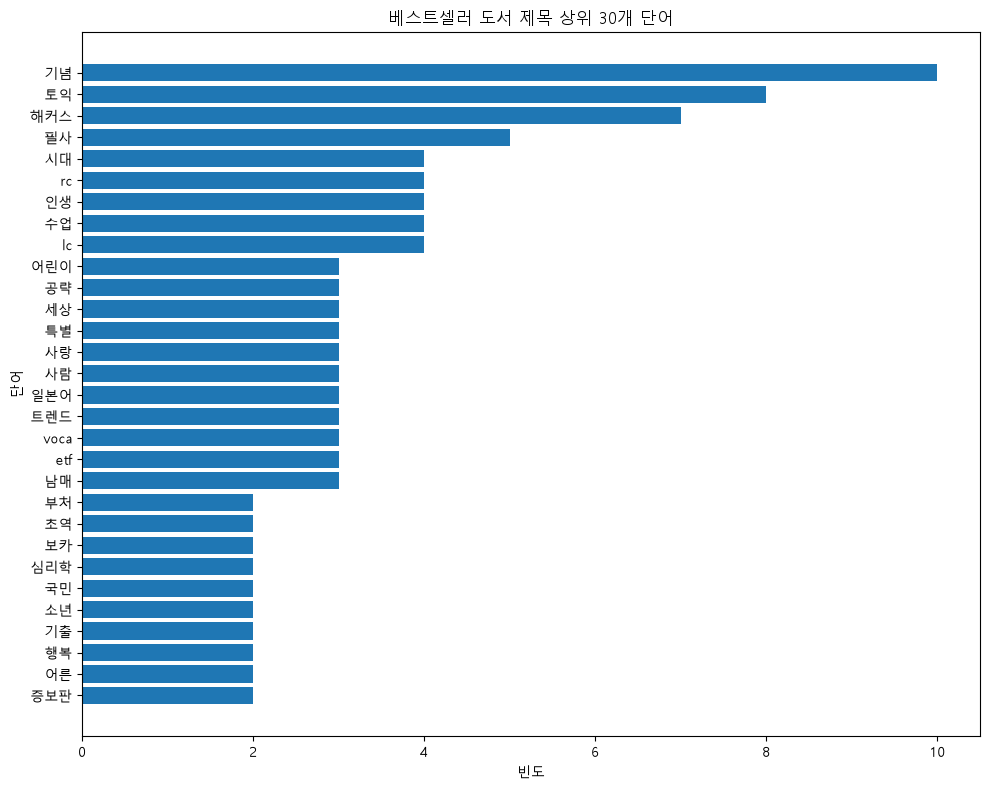

In [35]:
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프용 데이터 정렬
plot_data = top30.sort_values("빈도", ascending=True)

# 그래프 크기 설정
plt.figure(figsize=(10, 8))

# 가로 막대그래프 그리기
plt.barh(plot_data["단어"], plot_data["빈도"])

# 축 제목 설정
plt.xlabel("빈도")
plt.ylabel("단어")

# 그래프 제목
plt.title("베스트셀러 도서 제목 상위 30개 단어")

# 그래프가 잘리지 않도록 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 상위 30개 단어 막대그래프 분석 결과

- 가장 많이 등장한 단어는 `기념`으로 **10회**였다.
- 그다음은 `토익` 8회, `해커스` 7회, `필사` 5회 순으로 나타났다.
- `시대`, `인생`, `수업`, `트렌드`, `일본어`처럼 도서 주제와 관련된 단어들도 확인되었다.
- 표에서 확인한 빈도와 막대 길이가 자연스럽게 대응했고, 한글도 깨지지 않고 정상적으로 표시되었다.
- 막대그래프를 통해 단어별 빈도 차이를 Word Cloud보다 더 정확하게 비교할 수 있었다.

### 실습 20. Word Cloud 설치하기

이번 실습에서는 단어 빈도를 시각화하기 위해 `wordcloud` 라이브러리를 설치한다.

- `python -m pip install wordcloud matplotlib` → Word Cloud와 그래프 라이브러리 설치
- `python -m pip show wordcloud` → 설치 여부 확인
- `from wordcloud import WordCloud` → Notebook에서 정상적으로 불러와지는지 확인

설치가 완료되면 이후 단어 빈도 데이터를 이용해 Word Cloud를 만들 수 있다.

In [36]:
# Word Cloud 라이브러리 불러오기
from wordcloud import WordCloud

print("\n====WordCloud 불러오기 결과:=======")
print("WordCloud import 성공")


====WordCloud 불러오기 결과:=======
WordCloud import 성공


### Word Cloud 라이브러리 설치 확인 결과

- `wordcloud` 라이브러리가 정상적으로 설치되었다.
- Notebook에서 `from wordcloud import WordCloud` 코드가 오류 없이 실행되었다.
- 출력 결과에서 `WordCloud import 성공`을 확인했다.
- 이제 단어 빈도 데이터를 이용해 Word Cloud 시각화를 만들 수 있는 상태이다.

### 실습 21. Word Cloud용 한글 폰트 확인하기

Word Cloud에서 한글이 깨지지 않도록 한글 폰트 파일 경로를 확인한다.

- `Path()` → 폰트 파일 경로 지정
- `exists()` → 해당 폰트 파일이 실제로 존재하는지 확인
- 결과가 `True`면 해당 폰트를 Word Cloud에 사용할 수 있다.
- `False`라면 내 PC에 설치된 다른 한글 폰트 경로를 찾아야 한다.

폰트 경로는 PC와 운영체제 환경에 따라 달라질 수 있다.

In [37]:
from pathlib import Path

# 한글 폰트 경로 지정
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 폰트 파일 존재 여부 확인
print("\n====한글 폰트 파일 존재 여부:=======")
print(FONT_PATH.exists())

# 사용할 폰트 경로 확인
print("\n====사용할 폰트 경로:=======")
print(FONT_PATH)


====한글 폰트 파일 존재 여부:=======
True

====사용할 폰트 경로:=======
C:\Windows\Fonts\malgun.ttf


### Word Cloud 한글 폰트 확인 결과

- `C:/Windows/Fonts/malgun.ttf` 경로의 한글 폰트 존재 여부를 확인했다.
- `FONT_PATH.exists()` 결과가 **True**로 나와 맑은 고딕 폰트를 사용할 수 있음을 확인했다.
- 사용할 폰트 경로도 정상적으로 출력되었다.
- 이제 이 폰트 경로를 Word Cloud 생성 코드에 넣어 한글을 정상적으로 표시할 수 있다.

### 실습 22. Word Cloud 생성하기

이번 실습에서는 `final_counter`에 저장된 단어 빈도를 이용해 Word Cloud를 만든다.

- `WordCloud()` → Word Cloud 설정
- `generate_from_frequencies(final_counter)` → 단어 빈도로 Word Cloud 생성
- `plt.imshow()` → 화면에 출력
- `to_file()` → 이미지 파일로 저장
- `Path(...).exists()` → 저장 여부 확인

즉,  
`단어 빈도 준비 → Word Cloud 생성 → 화면 출력 → 이미지 저장 → 파일 확인`  
순서로 진행한다.

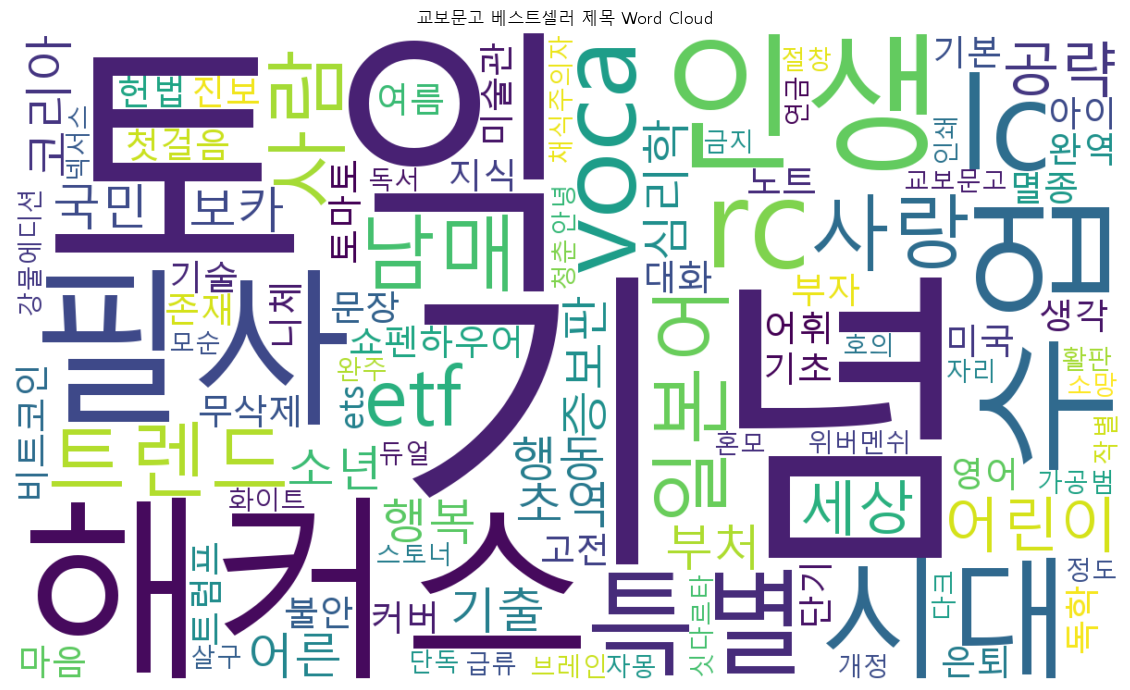


====Word Cloud 이미지 저장 여부:=======
True

====저장된 파일명:=======
chapter02_wordcloud.png


In [38]:
from wordcloud import WordCloud
from pathlib import Path
import matplotlib.pyplot as plt

# Word Cloud 만들기
wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

# 화면 출력
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

# 이미지 파일 저장
wordcloud.to_file("chapter02_wordcloud.png")

# 저장 여부 확인
print("\n====Word Cloud 이미지 저장 여부:=======")
print(Path("chapter02_wordcloud.png").exists())

print("\n====저장된 파일명:=======")
print("chapter02_wordcloud.png")

### Word Cloud 생성 결과

- `final_counter`의 단어 빈도를 이용해 Word Cloud를 정상적으로 생성했다.
- `기념`, `토익`, `해커스`, `필사`, `인생`, `시대`, `사람` 등 빈도가 높은 단어가 크게 표시되었다.
- 단어의 크기를 통해 어떤 단어가 자주 등장했는지 한눈에 확인할 수 있었다.
- 한글 폰트도 정상적으로 적용되어 글자가 깨지지 않았다.
- 막대그래프는 정확한 빈도 비교에 좋고, Word Cloud는 전체적인 주요 단어를 빠르게 파악하는 데 유용하다.

### 실습 23. Word Cloud 해석하기

Word Cloud에서 글자가 크게 보인다는 것은 **이번 분석에서 해당 단어가 더 자주 등장했다는 뜻**이다.

예를 들어 `기념`, `토익`, `해커스` 같은 단어가 크게 보였다면,  
베스트셀러 도서 제목에서 이런 단어가 상대적으로 자주 사용되었다고 해석할 수 있다.

하지만 이것만으로 해당 주제가 판매의 원인이라거나, 독자들이 가장 좋아하는 주제라고 판단할 수는 없다.

이번 분석은 **도서 제목에 등장한 단어의 빈도**를 확인한 것이므로,  
`자주 등장한 단어 = 판매 원인`으로 해석하면 안 된다.

In [39]:
# Word Cloud 해석을 위해 상위 단어 확인
print("\n====Word Cloud 해석용 상위 10개 단어:=======")
print(final_counter.most_common(10))

# 해석 기준 안내
print("\n====해석 기준:=======")
print("글자가 클수록 도서 제목에서 더 자주 등장한 단어이다.")
print("단어 빈도가 높다고 해서 판매 원인이나 독자 선호를 의미하는 것은 아니다.")
print("이번 분석은 도서 제목에 등장한 단어 빈도를 확인한 것이다.")


====Word Cloud 해석용 상위 10개 단어:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]

====해석 기준:=======
글자가 클수록 도서 제목에서 더 자주 등장한 단어이다.
단어 빈도가 높다고 해서 판매 원인이나 독자 선호를 의미하는 것은 아니다.
이번 분석은 도서 제목에 등장한 단어 빈도를 확인한 것이다.


### Word Cloud 해석 결과

- 상위 단어는 `기념` 10회, `토익` 8회, `해커스` 7회, `필사` 5회 순으로 확인되었다.
- Word Cloud에서 글자가 크게 보이는 단어는 도서 제목에서 상대적으로 자주 등장한 단어이다.
- 하지만 빈도가 높다고 해서 해당 주제가 판매의 원인이나 독자의 선호를 직접 의미하는 것은 아니다.
- 이번 분석은 어디까지나 **베스트셀러 도서 제목에 등장한 단어의 빈도**를 확인한 결과이다.

### 실습 24. 상위 단어를 원본 제목에서 다시 확인하기

이번 실습에서는 빈도 분석에서 많이 나온 단어가 실제 도서 제목에서 어떻게 사용되었는지 확인한다.

- `top30.iloc[0]["단어"]` → 가장 빈도가 높은 단어 선택
- `str.contains()` → 해당 단어가 포함된 원본 상품명 검색
- `상품명`, `분야`를 함께 확인해 단어가 어떤 문맥에서 사용됐는지 살펴본다.

이 과정을 통해 단어 빈도 결과가 실제 제목과 잘 연결되는지 검증할 수 있다.

In [40]:
# 상위 단어 중 첫 번째 단어 선택
target_word = top30.iloc[0]["단어"]

print("\n====확인할 상위 단어:=======")
print(target_word)

# 원본 상품명에서 해당 단어가 들어 있는 제목 찾기
matched_titles = df_books[
    df_books["상품명"].astype(str).str.contains(
        str(target_word),
        case=False,
        na=False,
        regex=False
    )
][["상품명", "분야"]]

# 검색 결과 개수 확인
print("\n====해당 단어가 포함된 제목 개수:=======")
print(len(matched_titles))

# 앞의 20개 결과 확인
print("\n====원본 제목 확인:=======")
display(matched_titles.head(20))


====확인할 상위 단어:=======
기념

====해당 단어가 포함된 제목 개수:=======
10

====원본 제목 확인:=======


,상품명,분야
20,쇼펜하우어 인생수업(30만 부 기념 개정증보판),인문
22,행복할 거야 이래도 되나 싶을 정도로(10만 부 기념 교보문고 단독 리커버),시/에세이
29,돈의 심리학(30만 부 기념 스페셜 에디션),경제/경영
44,퓨처 셀프 30만 부 기념 스페셜 에디션,자기계발
78,꽃을 보듯 너를 본다(100만 부 기념 에디션)(리커버:K),시/에세이
109,기분이 태도가 되지 말자(30만부 기념 최신 개정판),시/에세이
111,부자 아빠 가난한 아빠(20주년 특별 기념판),경제/경영
131,왜 나는 너를 사랑하는가(70만 부 기념 리커버),소설
147,제로 투 원(10주년 기념판),경제/경영
149,아주 작은 습관의 힘(50만 부 기념 스페셜 에디션),자기계발


### 상위 단어 원본 제목 검증 결과

- 가장 빈도가 높은 단어인 `기념`을 원본 도서 제목에서 다시 확인했다.
- `기념`이 포함된 제목은 총 **10개**로 확인되었다.
- 실제 제목을 확인해 보니 `30만 부 기념`, `10만 부 기념`, `20주년 특별 기념판`처럼 다양한 형태로 사용되고 있었다.
- 분야도 인문, 시/에세이, 경제/경영, 자기계발, 소설 등 여러 분야에 걸쳐 있었다.
- 따라서 `기념`은 특정 주제를 나타내는 단어라기보다 **판매량·출간 이벤트·특별판을 설명하는 표현**으로 자주 사용된 것으로 볼 수 있다.
- 이런 식으로 상위 단어는 반드시 원본 제목에서 다시 확인해야 실제 의미를 더 정확하게 해석할 수 있다.

### 실습 25. 상위 10개 단어와 전체 빈도 검증하기

이번 실습에서는 빈도 분석 결과가 논리적으로 맞는지 다시 확인한다.

- `most_common(10)` → 상위 10개 단어와 빈도 확인
- `top30.head(10)` → DataFrame 결과와 비교
- `sum(final_counter.values())` → 전체 빈도 합 확인
- `len(final_words)` → 실제 추출된 전체 단어 수 확인

두 결과가 서로 같다면 빈도 계산이 정상적으로 이루어진 것으로 볼 수 있다.

In [41]:
# 상위 10개 단어 확인
top10 = final_counter.most_common(10)

print("\n====Counter 상위 10개 단어:=======")
print(top10)

print("\n====DataFrame 상위 10개 단어:=======")
print(top30.head(10).values.tolist())

# 전체 빈도 합과 단어 수 비교
print("\n====Counter 전체 빈도 합:=======")
print(sum(final_counter.values()))

print("\n====final_words 전체 길이:=======")
print(len(final_words))


====Counter 상위 10개 단어:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]

====DataFrame 상위 10개 단어:=======
[['기념', 10], ['토익', 8], ['해커스', 7], ['필사', 5], ['인생', 4], ['수업', 4], ['시대', 4], ['lc', 4], ['rc', 4], ['특별', 3]]

====Counter 전체 빈도 합:=======
433

====final_words 전체 길이:=======
433


### 상위 10개 단어 및 전체 빈도 검증 결과

- `Counter`의 상위 10개 결과와 `top30` DataFrame의 상위 10개 결과가 동일하게 확인되었다.
- 상위 단어는 `기념` 10회, `토익` 8회, `해커스` 7회, `필사` 5회 등이었다.
- `Counter`의 전체 빈도 합은 **433**으로 확인되었다.
- `final_words`의 전체 길이도 **433**으로 동일했다.
- 따라서 단어 추출 결과와 빈도 계산 결과가 서로 일치하며 정상적으로 집계된 것을 확인했다.

### 실습 26. 불용어 적용 전후 비교하기

이번 실습에서는 불용어를 적용하기 전과 후의 상위 단어를 나란히 비교한다.

- `noun_counter` → 불용어 적용 전 빈도
- `final_counter` → 불용어 적용 후 빈도
- `pd.concat()` → 적용 전/후 결과를 한 표에서 비교

확인할 것은 다음과 같다.

- 제거하려던 단어가 실제로 사라졌는지
- 중요한 단어까지 같이 사라지지 않았는지
- 상위 단어 순위가 어떻게 바뀌었는지
- 왜 해당 단어를 불용어로 지정했는지 설명할 수 있는지

불용어는 분석 결과에 직접 영향을 주므로, 최종 결과에 사용한 기준을 함께 기록하는 것이 중요하다.

In [42]:
# 불용어 적용 전 상위 20개
before_top20 = pd.DataFrame(
    noun_counter.most_common(20),
    columns=["적용 전 단어", "적용 전 빈도"]
)

# 불용어 적용 후 상위 20개
after_top20 = pd.DataFrame(
    final_counter.most_common(20),
    columns=["적용 후 단어", "적용 후 빈도"]
)

# 적용 전/후 결과 나란히 비교
comparison = pd.concat(
    [before_top20, after_top20],
    axis=1
)

# 결과 확인
print("\n====불용어 적용 전후 비교:=======")
display(comparison)

# 현재 사용한 불용어 확인
print("\n====사용한 불용어 목록:=======")
print(STOPWORDS)


====불용어 적용 전후 비교:=======


,적용 전 단어,적용 전 빈도,적용 후 단어,적용 후 빈도
0,에디션,14,기념,10
1,기념,10,토익,8
2,토익,8,해커스,7
3,해커스,7,필사,5
4,리커버,7,인생,4
5,스페셜,5,수업,4
6,필사,5,시대,4
7,인생,4,lc,4
8,수업,4,rc,4
9,시대,4,특별,3



====사용한 불용어 목록:=======
{'개정판', '세트', '한정판', '리커버', '에디션', '스페셜'}


### 불용어 적용 전후 비교 결과

- 불용어 적용 전에는 `에디션`, `리커버`, `스페셜`, `한정판`처럼 도서의 형식이나 판형을 나타내는 단어가 상위에 있었다.
- 불용어 적용 후에는 해당 단어들이 제거되고 `기념`, `토익`, `해커스`, `필사`, `인생`, `수업`, `시대` 등이 상위에 나타났다.
- 불용어를 제거하면서 상위 순위가 바뀌었고, 실제 도서 주제와 관련된 단어가 더 잘 보이게 되었다.
- 사용한 불용어는 `개정판`, `세트`, `한정판`, `리커버`, `에디션`, `스페셜`이다.
- 중요한 단어까지 과도하게 제거하지 않고, 분석 목적과 관계가 적은 표현만 제외하는 것이 중요하다.

### 실습 27. 인공지능에게 결과 해석 요청하기

이번 실습에서는 Notebook에서 실제로 나온 단어 빈도 결과를 인공지능에게 전달해 해석 초안을 만든다.

- 실제 상위 단어와 빈도 결과를 함께 제공한다.
- 분석 조건인 `Kiwi`, `NNG/NNP/SL`, 2글자 이상, 불용어 제거 기준도 함께 적는다.
- 인공지능에게 판매 원인처럼 과도하게 해석하지 않도록 조건을 준다.
- 작성된 해석은 반드시 실제 Notebook 결과와 다시 비교한다.

핵심은 **데이터 없이 해석을 맡기는 것이 아니라, 실제 결과를 근거로 해석을 보조받는 것**이다.

In [43]:
# 실제 상위 10개 단어 결과 확인
top10_result = final_counter.most_common(10)

print("\n====실제 상위 10개 단어 결과:=======")
print(top10_result)

# 분석 조건 확인
print("\n====분석 조건:=======")
print("형태소 분석: Kiwi")
print("사용 품사: NNG, NNP, SL")
print("최소 글자 수: 2글자 이상")
print("불용어 제거: 적용")
print("확인 범위: 빈도 상위 30개")

# AI에게 전달할 내용 확인
print("\n====AI 해석 요청에 사용할 실제 결과:=======")
for word, count in top10_result:
    print(word, count)


====실제 상위 10개 단어 결과:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]

====분석 조건:=======
형태소 분석: Kiwi
사용 품사: NNG, NNP, SL
최소 글자 수: 2글자 이상
불용어 제거: 적용
확인 범위: 빈도 상위 30개

====AI 해석 요청에 사용할 실제 결과:=======
기념 10
토익 8
해커스 7
필사 5
인생 4
수업 4
시대 4
lc 4
rc 4
특별 3


### AI 해석 요청용 실제 결과 정리

- 형태소 분석은 `Kiwi`를 사용했다.
- 분석 품사는 `NNG`, `NNP`, `SL`로 제한했다.
- 2글자 이상 단어만 사용하고 불용어를 제거했다.
- 실제 상위 단어는 `기념 10`, `토익 8`, `해커스 7`, `필사 5`, `인생 4`, `수업 4`, `시대 4`, `lc 4`, `rc 4`, `특별 3`으로 확인되었다.
- 이 결과를 기준으로만 해석하고, 판매 원인이나 독자 선호까지 확대 해석하지 않도록 한다.

## 단어 빈도 분석 결과

교보문고 베스트셀러 도서 제목을 대상으로 단어 빈도를 확인했다.

Kiwi 형태소 분석기를 이용해 `NNG`, `NNP`, `SL` 품사를 추출했고,  
2글자 이상 단어만 사용한 뒤 분석 목적과 관계가 적은 일부 표현을 불용어로 제거했다.

빈도 상위 단어는 다음과 같았다.

- 1위: `기념` (10회)
- 2위: `토익` (8회)
- 3위: `해커스` (7회)

Word Cloud에서도 빈도가 높은 단어가 상대적으로 크게 표시되는 것을 확인했다.

다만 이 결과는 **도서 제목에서 자주 등장한 단어를 보여주는 것**이며,  
해당 단어가 도서 판매의 원인이나 독자 선호를 의미하는 것은 아니다.

In [44]:
# 상위 3개 단어 가져오기
top3 = final_counter.most_common(3)

print("\n====단어 빈도 분석 상위 3개:=======")
for rank, (word, count) in enumerate(top3, start=1):
    print(f"{rank}위: {word} ({count}회)")

print("\n====분석 조건:=======")
print("형태소 분석기: Kiwi")
print("사용 품사: NNG, NNP, SL")
print("최소 글자 수: 2글자 이상")
print("불용어 제거: 적용")

print("\n====해석 주의사항:=======")
print("이 결과는 도서 제목에서 자주 등장한 단어를 보여준다.")
print("단어 빈도가 높다고 해서 판매 원인이나 독자 선호를 의미하는 것은 아니다.")


====단어 빈도 분석 상위 3개:=======
1위: 기념 (10회)
2위: 토익 (8회)
3위: 해커스 (7회)

====분석 조건:=======
형태소 분석기: Kiwi
사용 품사: NNG, NNP, SL
최소 글자 수: 2글자 이상
불용어 제거: 적용

====해석 주의사항:=======
이 결과는 도서 제목에서 자주 등장한 단어를 보여준다.
단어 빈도가 높다고 해서 판매 원인이나 독자 선호를 의미하는 것은 아니다.


## 단어 빈도 분석 결과

교보문고 베스트셀러 도서 제목을 대상으로 단어 빈도를 확인했다.

Kiwi 형태소 분석기를 이용해 일반 명사, 고유 명사, 영문 토큰을 추출했고,  
2글자 이상 단어를 사용한 뒤 분석 목적과 관계가 적은 일부 표현을 불용어로 제거했다.

빈도 상위 단어는 다음과 같았다.

- 1위: `기념` (10회)
- 2위: `토익` (8회)
- 3위: `해커스` (7회)

Word Cloud에서도 빈도가 높은 단어가 상대적으로 크게 표시되는 것을 확인했다.

다만 이 결과는 도서 제목에서 자주 등장한 단어를 보여주는 것이며,  
해당 단어가 도서 판매의 원인이나 독자 선호를 의미하는 것은 아니다.

### 실습 29. 전체 분석 흐름 한 번에 확인하기

이번 실습에서는 앞에서 단계별로 진행했던 과정을 하나의 코드로 연결해 전체 흐름을 다시 확인한다.

핵심 흐름은 다음과 같다.

`CSV 불러오기 → 상품명 준비 → Kiwi 형태소 분석 → 품사/길이/불용어 필터링 → 단어 빈도 계산 → 상위 30개 표 생성 → CSV 저장 → Word Cloud 생성 → 최종 검증`

이 코드는 새로운 내용을 배우는 단계라기보다, 앞에서 학습한 각 과정이 어떻게 하나의 분석 과정으로 연결되는지 확인하는 최종 점검용 코드이다.


====데이터 불러오기:=======
(199, 8)

====분석에 사용할 제목 수:=======
199

====분석 조건:=======
사용 품사: {'NNG', 'NNP', 'SL'}
최소 글자 수: 2
불용어: {'개정판', '세트', '한정판', '리커버', '에디션', '스페셜'}

====최종 단어 수:=======
433

====최종 단어 앞 50개:=======
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕', '호의']

====상위 10개 단어:=======
[('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]

====상위 30개 단어 표:=======


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,필사,5
4,인생,4
5,수업,4
6,시대,4
7,lc,4
8,rc,4
9,특별,3



====상위 30개 CSV 저장 여부:=======
True


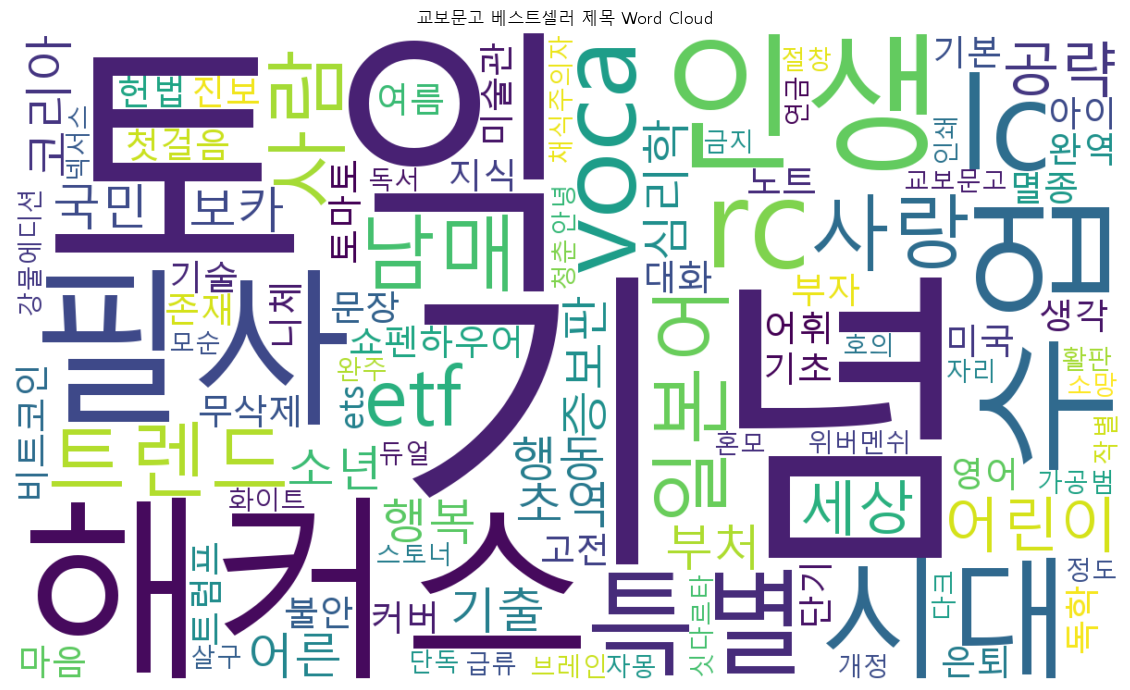


====Word Cloud 이미지 저장 여부:=======
True

====최종 분석 검증:=======
사용한 제목 수: 199
최종 단어 수: 433
Counter 빈도 합: 433
Top 10: [('기념', 10), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]


In [45]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from wordcloud import WordCloud

# 1. 데이터 불러오기
DATA_PATH = "book_bestseller_clean.csv"
df_books = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("\n====데이터 불러오기:=======")
print(df_books.shape)

# 2. 상품명 준비
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# 빈 제목 제거
titles = titles[titles != ""]

print("\n====분석에 사용할 제목 수:=======")
print(len(titles))

# 3. 형태소 분석 조건 준비
kiwi = Kiwi()

TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2

STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
    "스페셜",
}

print("\n====분석 조건:=======")
print("사용 품사:", TARGET_TAGS)
print("최소 글자 수:", MIN_LENGTH)
print("불용어:", STOPWORDS)

# 4. 단어 추출 함수
def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):

        # 사용할 품사가 아니면 제외
        if token.tag not in TARGET_TAGS:
            continue

        # 단어 정리
        word = token.form.strip().lower()

        # 2글자 미만 제외
        if len(word) < MIN_LENGTH:
            continue

        # 불용어 제외
        if word in STOPWORDS:
            continue

        result.append(word)

    return result

# 5. 모든 제목에서 단어 추출
final_words = []

for title in titles:
    final_words.extend(extract_words(title))

print("\n====최종 단어 수:=======")
print(len(final_words))

print("\n====최종 단어 앞 50개:=======")
print(final_words[:50])

# 6. 단어 빈도 계산
final_counter = Counter(final_words)

print("\n====상위 10개 단어:=======")
print(final_counter.most_common(10))

# 7. 상위 30개를 DataFrame으로 변환
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n====상위 30개 단어 표:=======")
display(top30)

# 8. 결과 CSV 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n====상위 30개 CSV 저장 여부:=======")
print(Path("chapter02_top30_words.csv").exists())

# 9. Word Cloud 생성
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

if not FONT_PATH.exists():
    raise FileNotFoundError(
        f"한글 폰트 파일을 찾을 수 없습니다: {FONT_PATH}"
    )

wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42
).generate_from_frequencies(final_counter)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

# Word Cloud 이미지 저장
wordcloud.to_file("chapter02_wordcloud.png")

print("\n====Word Cloud 이미지 저장 여부:=======")
print(Path("chapter02_wordcloud.png").exists())

# 10. 최종 검증
print("\n====최종 분석 검증:=======")
print("사용한 제목 수:", len(titles))
print("최종 단어 수:", len(final_words))
print("Counter 빈도 합:", sum(final_counter.values()))
print("Top 10:", final_counter.most_common(10))